## Анализ ключевых HR-метрик

Предоставлены данные о 311 сотрудниках компании. 
Задача — изучить данные, расчитать основные метрики:
- Retention Rate (коэффициент удержания сотрудников),   
- Средний стаж работы в компании (Average Tenure),   
- Коэффициент текучести кадров (Turnover Rate),  
- Причины увольнения, 
- Результаты перформанс ревью (Performance Metrics).

В ходе анализа найти закономерности и сформулировать рекомендации для повышения эффективности HR-процессов.

### Шаг 1. Импортируем нужные для работы библиотеки и считываем данные

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('~/hr_project/HRDataset_v14.csv', parse_dates=['DateofHire', 'DateofTermination', 'DOB', 'LastPerformanceReview_Date'])

### Шаг 2. Изучаем данные, меняем форматы, наименования нужных полей, проверяем наличие пропусков и дубликатов.

In [3]:
df.head(10)

,Employee_Name,EmpID,MarriedID,MaritalStatusID,GenderID,EmpStatusID,DeptID,PerfScoreID,FromDiversityJobFairID,Salary,...,ManagerName,ManagerID,RecruitmentSource,PerformanceScore,EngagementSurvey,EmpSatisfaction,SpecialProjectsCount,LastPerformanceReview_Date,DaysLateLast30,Absences
0,"Adinolfi, Wilson K",10026,0,0,1,1,5,4,0,62506,...,Michael Albert,22.0,LinkedIn,Exceeds,4.60,5,0,2019-01-17,0,1
1,"Ait Sidi, Karthikeyan",10084,1,1,1,5,3,3,0,104437,...,Simon Roup,4.0,Indeed,Fully Meets,4.96,3,6,2016-02-24,0,17
2,"Akinkuolie, Sarah",10196,1,1,0,5,5,3,0,64955,...,Kissy Sullivan,20.0,LinkedIn,Fully Meets,3.02,3,0,2012-05-15,0,3
3,"Alagbe,Trina",10088,1,1,0,1,5,3,0,64991,...,Elijiah Gray,16.0,Indeed,Fully Meets,4.84,5,0,2019-01-03,0,15
4,"Anderson, Carol",10069,0,2,0,5,5,3,0,50825,...,Webster Butler,39.0,Google Search,Fully Meets,5.00,4,0,2016-02-01,0,2
5,"Anderson, Linda",10002,0,0,0,1,5,4,0,57568,...,Amy Dunn,11.0,LinkedIn,Exceeds,5.00,5,0,2019-01-07,0,15
6,"Andreola, Colby",10194,0,0,0,1,4,3,0,95660,...,Alex Sweetwater,10.0,LinkedIn,Fully Meets,3.04,3,4,2019-01-02,0,19
7,"Athwal, Sam",10062,0,4,1,1,5,3,0,59365,...,Ketsia Liebig,19.0,Employee Referral,Fully Meets,5.00,4,0,2019-02-25,0,19
8,"Bachiochi, Linda",10114,0,0,0,3,5,3,1,47837,...,Brannon Miller,12.0,Diversity Job Fair,Fully Meets,4.46,3,0,2019-01-25,0,4
9,"Bacong, Alejandro",10250,0,2,1,1,3,3,0,50178,...,Peter Monroe,7.0,Indeed,Fully Meets,5.00,5,6,2019-02-18,0,16


In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 311 entries, 0 to 310
Data columns (total 36 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   Employee_Name               311 non-null    object        
 1   EmpID                       311 non-null    int64         
 2   MarriedID                   311 non-null    int64         
 3   MaritalStatusID             311 non-null    int64         
 4   GenderID                    311 non-null    int64         
 5   EmpStatusID                 311 non-null    int64         
 6   DeptID                      311 non-null    int64         
 7   PerfScoreID                 311 non-null    int64         
 8   FromDiversityJobFairID      311 non-null    int64         
 9   Salary                      311 non-null    int64         
 10  Termd                       311 non-null    int64         
 11  PositionID                  311 non-null    int64         

In [5]:
print(f'Дубликатов по EmpID: {df["EmpID"].duplicated().sum()}')

print(f'Полных дубликатов строк: {df.duplicated().sum()}')

Дубликатов по EmpID: 0
Полных дубликатов строк: 0


In [6]:
df['PerformanceScore'].unique()

array(['Exceeds', 'Fully Meets', 'Needs Improvement', 'PIP'], dtype=object)

In [7]:
df['Termd'] = df['Termd'].astype(bool)
perf_map = {'PIP': 1, 'Needs Improvement': 2, 'Fully Meets': 3, 'Exceeds': 4}
df['PerfScore'] = df['PerformanceScore'].map(perf_map)

In [8]:
#Создаём колонку TenureYears (стаж в годах)

ref_date = pd.Timestamp('2019-03-01')

df['TenureYears'] = 0.0

for i in df.index:
    hire_date = df.loc[i, 'DateofHire']          
    is_terminated = df.loc[i, 'Termd']            
    
    if is_terminated:
        term_date = df.loc[i, 'DateofTermination']
        days = (term_date - hire_date).days
    else:
        days = (ref_date - hire_date).days
    
    df.loc[i, 'TenureYears'] = days / 365.25

active = df[df['Termd'] == False]
terminated = df[df['Termd'] == True]

### Шаг 3. Считаем общее количество сотрудников, а также оценим текучесть за данный период

In [9]:
print('Период данных:')
print(f'Дата найма: от {df["DateofHire"].min().date()} до {df["DateofHire"].max().date()}')
print(f'Дата увольнения: от {terminated["DateofTermination"].min().date()} до {terminated["DateofTermination"].max().date()}')
print(f'Отчётная дата: {ref_date.date()}')

Период данных:
Дата найма: от 2006-01-09 до 2018-07-09
Дата увольнения: от 2010-08-30 до 2018-11-10
Отчётная дата: 2019-03-01


Всего сотрудников: 311
Активных: 207
Уволенных: 104
Коэффициент текучести (уволенные / всего): 33.44%


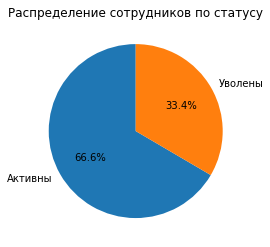

In [10]:
total = len(df)
print(f'Всего сотрудников: {total}')
print(f'Активных: {len(active)}')
print(f'Уволенных: {len(terminated)}')
print(f'Коэффициент текучести (уволенные / всего): {len(terminated)/total:.2%}')

# График
fig, ax = plt.subplots()
ax.pie([len(active), len(terminated)], labels=['Активны', 'Уволены'], autopct='%1.1f%%', startangle=90)
ax.set_title('Распределение сотрудников по статусу')
plt.show()

Текучесть по году найма:
    HireYear  Total  Terminated  TurnoverRate
0       2006      1           0      0.000000
1       2007      2           1      0.500000
2       2008      3           1      0.333333
3       2009      7           3      0.428571
4       2010      9           3      0.333333
5       2011     83          59      0.710843
6       2012     45          16      0.355556
7       2013     44           7      0.159091
8       2014     60           7      0.116667
9       2015     36           7      0.194444
10      2016     14           0      0.000000
11      2017      6           0      0.000000
12      2018      1           0      0.000000


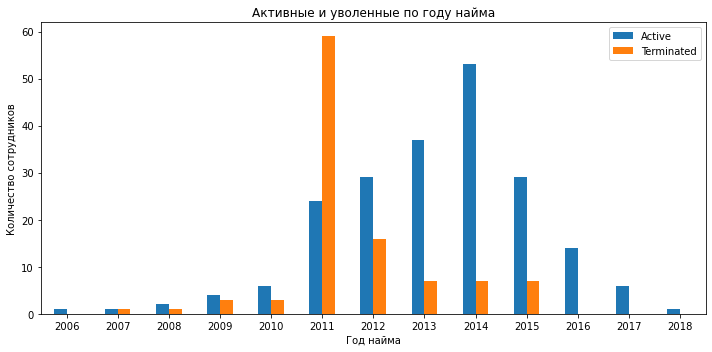

In [11]:
df['HireYear'] = df['DateofHire'].dt.year

yearly_stats = df.groupby('HireYear').agg(
    Total=('EmpID', 'count'),         
    Terminated=('Termd', 'sum')     
).reset_index()

yearly_stats['TurnoverRate'] = yearly_stats['Terminated'] / yearly_stats['Total']

print('Текучесть по году найма:')
print(yearly_stats)

yearly_stats['Active'] = yearly_stats['Total'] - yearly_stats['Terminated']   # оставшиеся
yearly_stats.plot(x='HireYear', y=['Active', 'Terminated'], kind='bar', figsize=(10,5))
plt.xlabel('Год найма')
plt.ylabel('Количество сотрудников')
plt.title('Активные и уволенные по году найма')
plt.xticks(rotation=0)
plt.legend()
plt.tight_layout()
plt.show()

### Промежуточные выводы

Коэффициент текучести 33.4% -  высокий, что говорит о серьезных проблемах в удержании.

Пик проблем – 2011 год: из 83 сотрудника было нанято, а уволено 59 человек (71%). Эта когорта внесла основной вклад в общий показатель 33.4% и искажает картину, маскируя улучшения в последующие годы.

Позитивная динамика с 2012 года: текучесть последовательно снижается: 2012 г. – 35.6%, 2013 г. – 15.9%, 2014 г. – 11.7%, 2015 г. – 19.4%. Это говорит о том, что после 2011 года меры по подбору и удержанию стали эффективнее.

Нулевая текучесть 2016–2018 гг. – ограниченная информативность: сотрудники этих лет найма работают менее 2–3 лет на момент отчётной даты (01.03.2019).

Общий вывод: проблема текучести не столько системная для всей истории компании, сколько сконцентрирована в «провальном» 2011 годе. Устранение причин, вызвавших массовый уход той когорты, и мониторинг новых наймов 2016+ позволят удержать общий показатель на безопасном уровне 15–20%.


### Шаг 4. Оценим текучесть в рамках департаментов

Текучесть по департаментам:
                      Total  Terminated  TurnoverRate
Department                                           
Admin Offices             9           2      0.222222
Executive Office          1           0      0.000000
IT/IS                    50          10      0.200000
Production              209          83      0.397129
Sales                    31           5      0.161290
Software Engineering     11           4      0.363636


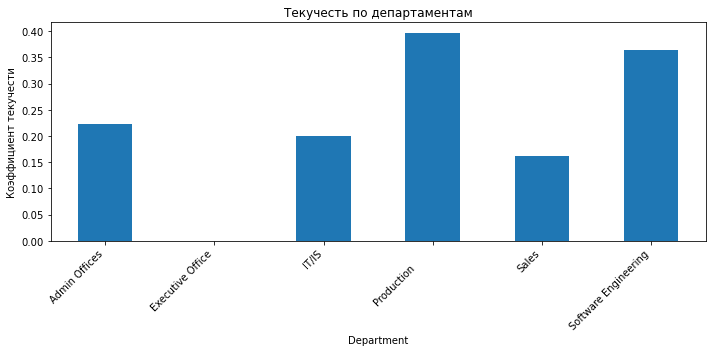

In [12]:
dept_turnover = df.groupby('Department').agg(
    Total=('Termd', 'count'),
    Terminated=('Termd', 'sum')
)
dept_turnover['TurnoverRate']= dept_turnover['Terminated'] / dept_turnover['Total']
print('Текучесть по департаментам:')
print(dept_turnover[['Total', 'Terminated', 'TurnoverRate']])

# График
fig, ax = plt.subplots(figsize=(10,5))
dept_turnover['TurnoverRate'].plot(kind='bar', ax=ax)
ax.set_ylabel('Коэффициент текучести')
ax.set_title('Текучесть по департаментам')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

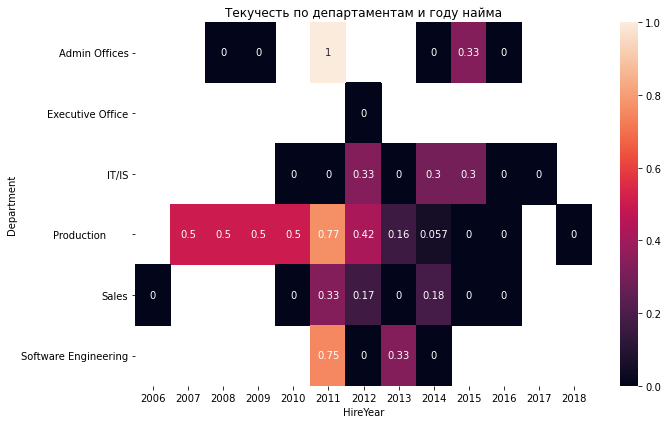

In [14]:
dept_year = df.groupby(['Department', 'HireYear']).agg(
    Total=('EmpID', 'count'),
    Terminated=('Termd', 'sum')
)
dept_year['TurnoverRate']= dept_year['Terminated'] / dept_year['Total']
pivot = dept_year.pivot_table(index='Department', columns='HireYear', values='TurnoverRate', aggfunc='mean')

plt.figure(figsize=(10,6))
sns.heatmap(pivot, annot=True)
plt.title('Текучесть по департаментам и году найма')
plt.tight_layout()
plt.show()


## Промежуточные выводы

Основной очаг текучести – Production: 39.7% при 209 сотрудниках (83 уволенных). Департамент формирует более 2/3 персонала, поэтому его показатели решающим образом влияют на общий коэффициент 33.4%. Без Production текучесть остальной компании была бы около 17.6% – близкой к норме.

Проблема локализована в 2011 году. Текучесть 77% в когорте найма 2011 г. (59 уволенных из 83) – основная причина общего высокого коэффициента. Уже в 2012 г. показатель падает до 42%, в 2014 – до 6%. Скорее всего было сокращение или другое событие, повлекшее массовое увольнение.


IT/IS и Sales демонстрируют стабильно контролируемую текучесть (10–30%) без аномалий. IT/IS, несмотря на высокую среднюю зарплату в целом, удерживает сотрудников успешно.

Динамика из года в год показывает, что компания после 2011 г. смогла выстроить процессы подбора и адаптации, которые смогли повлиять на снижение показателя. Текучесть в последних когортах для Production практически нулевая.

Риск: когорты 2016–2018 гг. пока не прошли пик рискового стажа (2–4 года), поэтому текущая нулевая текучесть может быть временной. Необходимо мониторить ситуацию.

### Шаг 5. Оценим причины увольнений


Причины увольнений:
another position                    20
unhappy                             14
more money                          11
career change                        9
hours                                8
attendance                           7
return to school                     5
relocation out of area               5
performance                          4
military                             4
retiring                             4
no-call, no-show                     4
maternity leave - did not return     3
medical issues                       3
learned that he is a gangster        1
fatal attraction                     1
gross misconduct                     1
Name: TermReason, dtype: int64


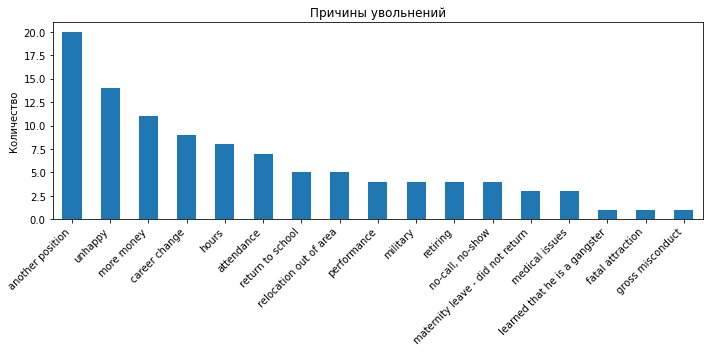

In [13]:
term_reasons = terminated['TermReason'].str.strip().str.lower().value_counts()
print('Причины увольнений:')
print(term_reasons)

# График
fig, ax = plt.subplots(figsize=(10,5))
term_reasons.plot(kind='bar', ax=ax)
ax.set_ylabel('Количество')
ax.set_title('Причины увольнений')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

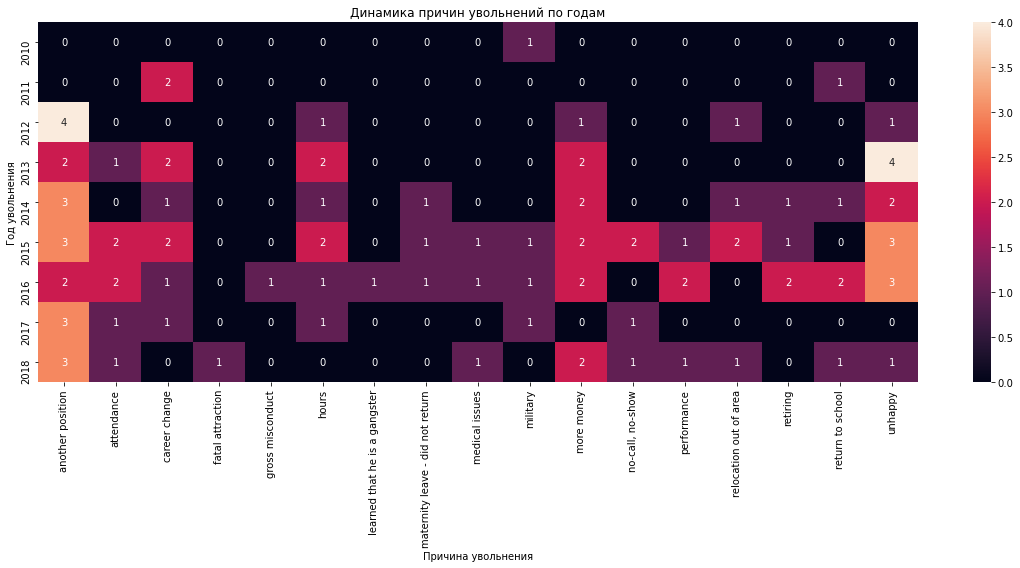

In [64]:
terminated['TermYear'] = terminated['DateofTermination'].dt.year
reasons_by_year = pd.crosstab(
    terminated['TermYear'],
    terminated['TermReason'].str.strip().str.lower()
)

plt.figure(figsize=(16,8))
sns.heatmap(reasons_by_year, annot=True)
plt.title('Динамика причин увольнений по годам')
plt.xlabel('Причина увольнения')
plt.ylabel('Год увольнения')
plt.tight_layout()
plt.show()



### Промежуточные выводы

Три доминирующие группы причин:

- Карьерно-финансовые: «another position» (20 случаев), «more money» (11), «career change» (9) – вместе 38.5% от всех увольнений. Люди уходят к конкурентам или в другие сферы из-за денег и перспектив.

- Психологический климат: «unhappy» (14) – вторая по частоте причина, чистый маркер неудовлетворённости.

- Организационные: «hours» (8), «attendance» (7) – отчасти добровольные (неудобный график), отчасти вынужденные (прогулы как следствие низкой вовлечённости).

80% увольнений – добровольные и предотвратимые (конкурентные переходы, неудовлетворённость, некомфортные условия). Лишь малая часть – увольнения по инициативе компании (performance, attendance, gross misconduct).

«Денежные» причины (more money + another position, часто тоже ради зарплаты) указывают на возможном отстовании в оплате труда от рынка, особенно критичный для массовых позиций Production, где текучесть максимальна.

Причина «unhappy» без детализации скрывает конкретные драйверы: стиль управления, переработки, проблемы с корпоративной культурой.

Пик увольнений пришёлся на 2015–2016 гг. (суммарно около 40% всех увольнений), причём в этот период одновременно росли все три ключевые группы причин: «another position», «more money», «unhappy» и «attendance». Это указывает на обострение проблем в середине десятилетия — вероятно, из-за сочетания рыночного давления и внутренних факторов.

Причина «unhappy» резко выросла в 2013 г. (4 случая) и оставалась значимой до 2016 г., после чего практически исчезла (0 в 2017 г., 1 в 2018 г.). Это положительная динакмика.

Финансовые причины («more money», «another position»)  присутствуют почти каждый год, но после 2016 г. их доля в общем снизившемся объёме увольнений стала уменьшаться. Тем не менее, они не исчезли полностью — значит, конкурентоспособность зарплат остаётся зоной внимания.

Причины «hours» и «attendance» фиксируются с 2012 по 2018 гг. с небольшой, но высокой частотой. Это может отражать хроническую неудовлетворённость графиком у части сотрудников.

Снижение абсолютного числа увольнений с 2017 г. при сохранении структуры причин подтверждает, что компания улучшила процессы удержания.

### Шаг 6. Оценим средний стаж работы сотрудников в компании


Средний стаж всех: 4.8 лет
Средний стаж уволенных: 3.5 лет
Средний стаж активных: 5.5 лет


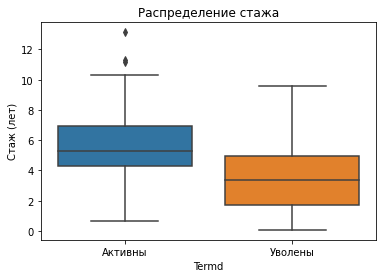

In [15]:
print(f'Средний стаж всех: {df["TenureYears"].mean():.1f} лет')
print(f'Средний стаж уволенных: {terminated["TenureYears"].mean():.1f} лет')
print(f'Средний стаж активных: {active["TenureYears"].mean():.1f} лет')

# График
fig, ax = plt.subplots()
sns.boxplot(x='Termd', y='TenureYears', data=df, ax=ax)
ax.set_xticklabels(['Активны', 'Уволены'])
ax.set_ylabel('Стаж (лет)')
ax.set_title('Распределение стажа')
plt.show()

Средний стаж (лет) по году найма:
HireYear
2006    13.1
2007     7.2
2008     9.5
2009     8.4
2010     6.6
2011     4.9
2012     5.6
2013     5.1
2014     4.4
2015     3.5
2016     2.7
2017     2.0
2018     0.6
Name: TenureYears, dtype: float64


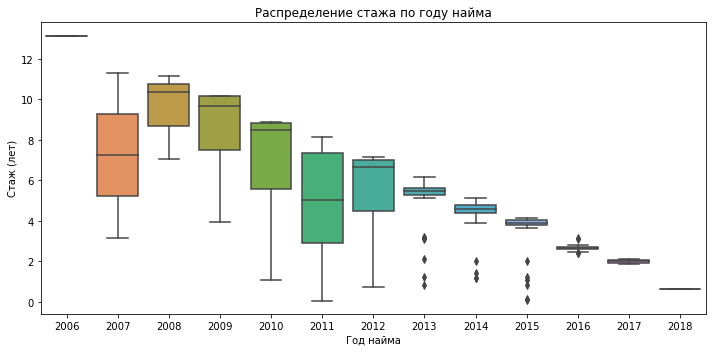

In [16]:
df['HireYear'] = df['DateofHire'].dt.year

active = df[~df['Termd']]
terminated = df[df['Termd']]

tenure_by_year = df.groupby('HireYear')['TenureYears'].mean()
print('Средний стаж (лет) по году найма:')
print(tenure_by_year.round(1))


fig, ax = plt.subplots(figsize=(10,5))
sns.boxplot(x='HireYear', y='TenureYears', data=df, ax=ax)
ax.set_xlabel('Год найма')
ax.set_ylabel('Стаж (лет)')
ax.set_title('Распределение стажа по году найма')
plt.tight_layout()
plt.show()


### Промежуточные выводы
Средний стаж уволенных на изучаемый период – 3.5 года, активных – 5.5 лет. Разрыв в 2 года подтверждает, что значительная доля уходов приходится на первые годы работы.

Boxplot демонстрирует, что распределение стажа уволенных смещено вниз: медиана и межквартильный размах находятся ниже 4 лет, тогда как у активных медиана около 5 лет с длинным «хвостом» вправо. 

Аномалия когорты 2011 года: при 8 годах, прошедших с найма до отчётной даты, средний стаж составляет всего 4.9 года. Это означает, что большинство уволенных покинули компанию в первые 3–4 года, не дожив до «зрелого» стажа. Именно эта когорта дала основной вклад в разрыв между средним стажем активных (5.5 лет) и уволенных (3.5 года).

Боксплот по годам найма визуально подтвердит: для 2011 года ящик с медианой смещён вниз, а усы обрезаны на низких значениях – многие уволились, проработав 1–3 года. Для 2012–2014 годов стаж уже выше, что коррелирует со снижением текучести.

Период 2016–2018 гг. показывает стаж 0.6–2.7 лет – эти сотрудники ещё находятся в «зоне риска» раннего ухода. Отсутствие увольнений в этих когортах пока не гарантирует их долгосрочное удержание, так как пик текучести ранее приходился на 2–4 год работы.

Реокмендация: основные усилия по удержанию должны быть направлены на сотрудников со стажем 1–3 года, а также на анализ причин, по которым когорта 2011 года была подвержена увольнению. Мониторинг новых наймов (2016+) позволит заранее выявить повторение сценария.

### Шаг 7. Оценим итоги перформанс сотрудников в компании
 

Распределение оценок ревью:
Fully Meets          243
Exceeds               37
Needs Improvement     18
PIP                   13
Name: PerformanceScore, dtype: int64
Средний балл по ревью:
2.98


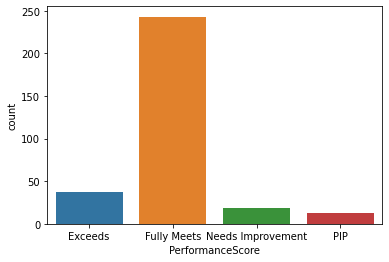

In [17]:
print('Распределение оценок ревью:')
print(df['PerformanceScore'].value_counts())
print('Средний балл по ревью:')
print(round(df['PerfScore'].mean(), 2))
sns.countplot(x=df['PerformanceScore'])
ax.set_title('Распределение перформанс-оценок')
plt.show()

In [18]:
df['PerfScore'].mean()

2.977491961414791

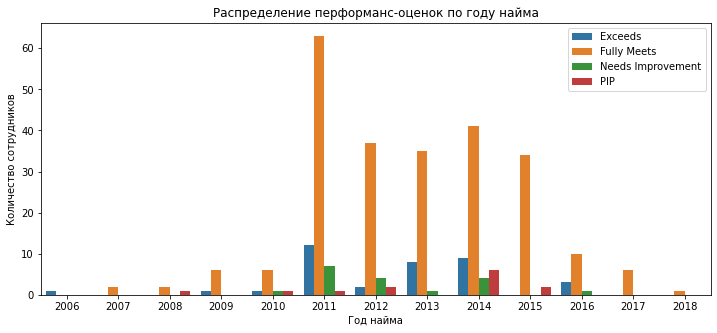

In [19]:
perfreview_data = df[['HireYear','PerformanceScore']]

fig, ax = plt.subplots(figsize=(12,5))
sns.countplot(x=perfreview_data['HireYear'], hue=perfreview_data['PerformanceScore'], data=perfreview_data)
ax.set_title('Распределение перформанс-оценок по году найма')
ax.set_xlabel('Год найма')
ax.set_ylabel('Количество сотрудников')
ax.legend(loc='upper right')

### Промежуточне выводы
Наибольшая доял у оценки «Fully Meets» (243 из 311) при среднем балле 2.98 (шкала 1-4).
Это указывает на то, что критичные оценки не используются руководителями. Возможно система оценок неэффективна.

Доля низких оценок (PIP + Needs Improvement) составляет 31 человек (~10%) – относительно немного. При этом текучесть в организации ~33%, увольнения не связаны с низкими оценками по ревью напрямую.

Сотрудников с наивысшей оценкой (Exceeds) 37 человек (11.9%). Их удержание критически важно, так как они делают большой вклад. Потеря даже нескольких таких сотрудников существенно ударит по производительности.



### Шаг 8. Изучим взаимосвязь оценок перформанс ревью и текучести

Доля уволенных по уровням Performance:
PerformanceScore
Exceeds              0.216216
Fully Meets          0.333333
Needs Improvement    0.555556
PIP                  0.384615
Name: EmpID, dtype: float64


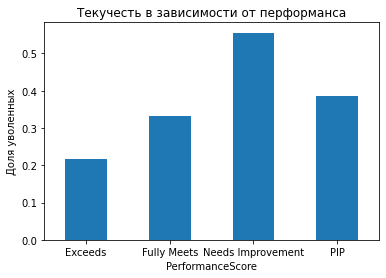

In [21]:
perf_term_rate = terminated.groupby('PerformanceScore')['EmpID'].count() / df.groupby('PerformanceScore')['EmpID'].count()
print('Доля уволенных по уровням Performance:')
print(perf_term_rate.sort_index())

# График
fig, ax = plt.subplots()
perf_term_rate.plot(kind='bar', ax=ax)
ax.set_ylabel('Доля уволенных')
ax.set_title('Текучесть в зависимости от перформанса')
plt.xticks(rotation=0)
plt.show()

### Промежуточне выводы

Доля уволенных среди Exceeds (21.6%) ниже средней текучести (33.4%), что говорит о некритичности риска увольнения среди данных сотрудников.
Однако ядро уволившихся сотрудников составляет грцппа с оценкой Fully Meets. Данная группа требует внимательно работы и изучения ситуации.


Needs Improvement (55.6%) и PIP (38.5%) имеют ожидаемо высокую текучесть, так у первой группы максимальный процент отток.
Это может быть признаком ухода слабых сотрудников, но также и признакомо возможно неэффективного процесса ревью.

Важный контекст: при смещённой системе оценок (78% Fully Meets) и малом количестве Exceeds, потеря даже нескольких высокорезультативных сотрудников наносит непропорционально большой урон.


### Шаг 9. Изучим взаимосвязь оценок перформанс ревью и текучестью

Средний балл Оценка вовлеченности: 4.11
Средний балл Оценка удовлетворенности: 3.8906752411575565

Вовлечённость и удовлетворённость по департаментам:
                      EngagementSurvey  EmpSatisfaction
Department                                             
Sales                         3.818710         4.032258
Software Engineering          4.061818         4.090909
Production                    4.129569         3.861244
IT/IS                         4.154000         3.960000
Admin Offices                 4.393333         3.555556
Executive Office              4.830000         3.000000


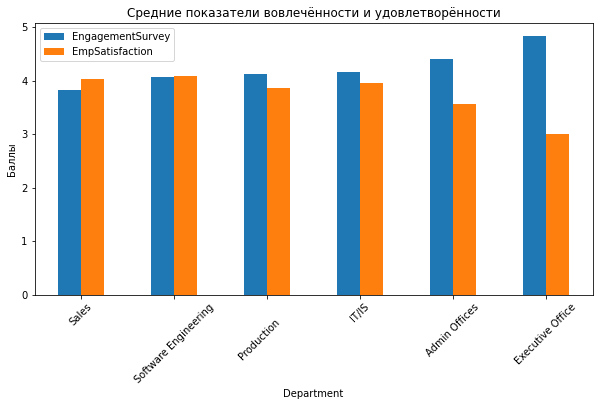

In [32]:
print(f'Средний балл Оценка вовлеченности: {df["EngagementSurvey"].mean()}')
print(f'Средний балл Оценка удовлетворенности: {df["EmpSatisfaction"].mean()}')

eng_dept = df.groupby('Department')[['EngagementSurvey', 'EmpSatisfaction']].mean().sort_values('EngagementSurvey')
print('\nВовлечённость и удовлетворённость по департаментам:')
print(eng_dept)

# График
fig, ax = plt.subplots(figsize=(10,5))
eng_dept.plot(kind='bar', ax=ax)
ax.set_title('Средние показатели вовлечённости и удовлетворённости')
ax.set_ylabel('Баллы')
plt.xticks(rotation=45)
plt.show()

### Промежуточные выводы

Общие средние оценки Вовлеченности и Удовлетсворенности имеют высокие оценки: 4.11 и 3.89 соответственно.

Однако в разрезе отделов выделяется департамент Sales: самая низкая вовлечённость (3.82) при одновременно самой высокой удовлетворённости (4.03). Это классический паттерн «комфортного болота»: сотрудники довольны условиями, но эмоционально не включены, не видят перспектив. Это прямой предиктор тихих увольнений и текучести при появлении лучшего предложения.

Sales – зона риска: самая низкая вовлечённость (3.82) при одновременно самой высокой удовлетворённости (4.03). Скорее всего сотрудники довольны условиями, но эмоционально не включены, не видят перспектив. Показатели требуют дополнительного внимания.

Admin Offices демонстрирует большой разрыв: очень высокая вовлечённость (4.39) при самой низкой удовлетворённости (3.56). Вероятен риск выгорания – люди горят работой, но не получают адекватного вознаграждения или признания.

Executive Office (1 сотрудник) – нерепрезентативен.

IT/IS и Software Engineering – относительное равновесие (обе метрики около 4.0), что коррелирует с их более низкой текучестью.

### Шаг 10. Оценим эффективность источников найма

Эффективность источников найма:
                         Hires  Turnover
RecruitmentSource                       
Indeed                      87  0.241379
LinkedIn                    76  0.236842
Google Search               49  0.612245
Employee Referral           31  0.161290
Diversity Job Fair          29  0.551724
CareerBuilder               23  0.478261
Website                     13  0.076923
Other                        2  0.500000
On-line Web application      1  1.000000


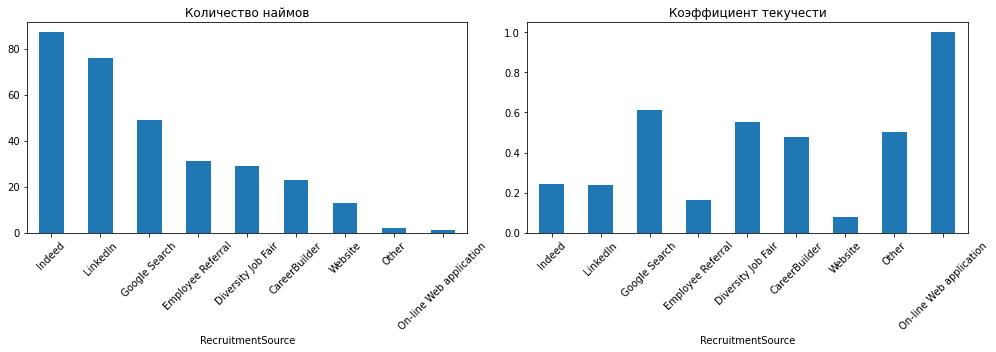

In [39]:
source_stats = df.groupby('RecruitmentSource').agg(
    Hires=('EmpID', 'count'),
    Turnover=('Termd', 'mean')
).sort_values('Hires', ascending=False)

print('Эффективность источников найма:')
print(source_stats)

# Графики
fig, axes = plt.subplots(1, 2, figsize=(14,5))
source_stats['Hires'].plot(kind='bar', ax=axes[0])
axes[0].set_title('Количество наймов')
axes[0].tick_params(axis='x', rotation=45)
source_stats['Turnover'].plot(kind='bar', ax=axes[1])
axes[1].set_title('Коэффициент текучести')
axes[1].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

### Промежуточные выводы

Реферальная система показывает себя как самый эффективный источник найма: увольнения за представленный период составляют 16.1%. Сотрудники, пришедшие по рекомендациям, лучше вписываются в культуру.

Карьерный сайт компании – сверхнизкая текучесть (7.7%), но малый объём найма (13). Сложно судить о качестве источника.

LinkedIn и Indeed – основные массовые каналы (76 и 87 наймов), текучесть на приемлемом уровне (~24%).

Google Search – критически высокая текучесть (61.2%) при почти 50 наймах. Вероятно, кандидаты приходят с завышенными ожиданиями или слабо таргетированы.

Diversity Job Fair, CareerBuilder – Высокий процент текучести (55.2% и 47.8%). Возможно, несовпадение корпоративной культуры или некачественный онбординг.

### Шаг 11. Рассмотрим распределние зарплатных вилок в разрезе департаментов.

Средняя и медианная зарплата по департаментам:
                               mean    median
Department                                   
Executive Office      250000.000000  250000.0
IT/IS                  97064.640000   92328.5
Software Engineering   94989.454545   95660.0
Admin Offices          71791.888889   63003.0
Sales                  69061.258065   65310.0
Production             59953.545455   59472.0


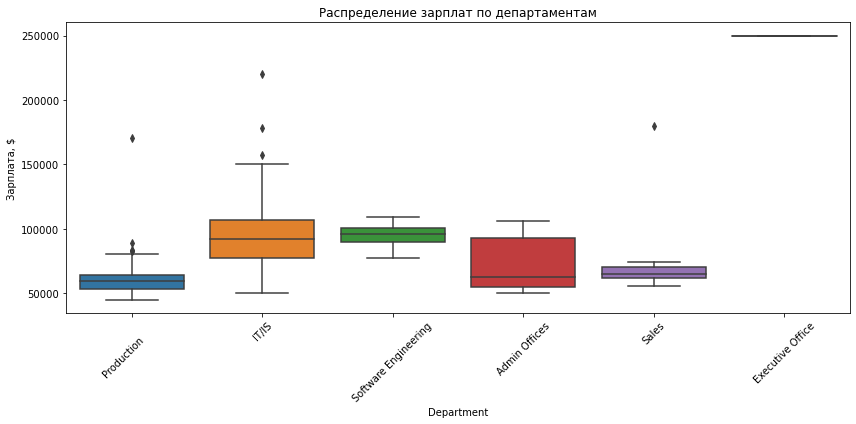

In [42]:
salary_dept = df.groupby('Department')['Salary'].agg(['mean', 'median']).sort_values('mean', ascending=False)
print('Средняя и медианная зарплата по департаментам:')
print(salary_dept)

# График через seaborn
fig, ax = plt.subplots(figsize=(12, 6))
sns.boxplot(x='Department', y='Salary', data=df, ax=ax)
ax.set_title('Распределение зарплат по департаментам')
ax.set_ylabel('Зарплата, $')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

### Промежуточные выводы

Production – самый низкооплачиваемый департамент.
При этом он крупнейший (209 человек) и с наивысшей текучестью (39.7%). Зарплатный разрыв с другими подразделениями очевиден: IT/IS получает на 60% больше, Sales – на 15%.

Executive Office (1 сотрудник, $250K) – CEO/президент, стандартная практика.

IT/IS и Software Engineering – сопоставимые уровни ($94–97K), медианы близки к средним, распределение без сильных перекосов.

Admin Offices – есть внутренний разрыв и выборсы в данных, что указывает на наличие нескольких высокооплачиваемых позиций на фоне более низких зарплат остальных.


### Шаг 11. Составим корреляционную матрицу ключевых метрик, чтобы найти зависимость между основными показателями

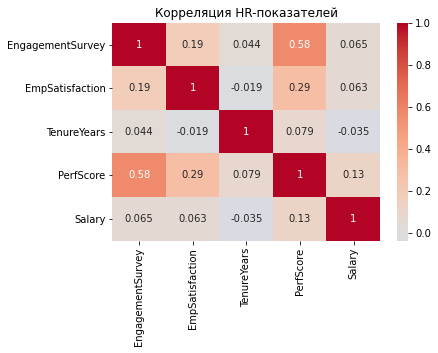

In [49]:
corr_cols = ['EngagementSurvey', 'EmpSatisfaction', 
             'TenureYears', 'PerfScore', 'Salary']
corr = df[corr_cols].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Корреляция HR-показателей')
plt.show()

### Выводы по корреляционной матрице

Большая зависимость между оценкой вовлеченности и результатами перформанс ревью (0.58). Рост вовлечённости на 1 балл сопровождается повышением перформанс-оценки в среднем на ~0.6 балла. Инвестиции в вовлечённость прямо конвертируются в производительность.

У остальных показателей связи слабые. Зарплата и стаж не объясняют ни производительность, ни вовлечённость.
Увольнения в первые годы — не следствие падения этих показателей, а внешних причин (карьера, деньги).

### Шаг 12. Отдельно изучим текучесть по менеджерам

In [50]:
mgr_turnover = df.groupby(['Department', 'ManagerName']).agg(
    Total=('EmpID', 'count'),
    Terminated=('Termd', 'sum')
)
mgr_turnover['TurnoverRate'] = mgr_turnover['Terminated'] / mgr_turnover['Total']
print(mgr_turnover.sort_values('TurnoverRate', ascending=False))

                                         Total  Terminated  TurnoverRate
Department           ManagerName                                        
Software Engineering Janet King              1           1      1.000000
Production           Webster Butler         21          13      0.619048
                     Amy Dunn               21          13      0.619048
                     Kissy Sullivan         22          12      0.545455
IT/IS                Simon Roup             17           8      0.470588
Production           Michael Albert         22           9      0.409091
                     Elijiah Gray           22           8      0.363636
                     Janet King             15           5      0.333333
Sales                Debra Houlihan          3           1      0.333333
Software Engineering Alex Sweetwater         9           3      0.333333
Admin Offices        Brandon R. LeBlanc      7           2      0.285714
Production           David Stanley          21     

### Основные рекомендации по итогам анализа


**Перформанс ревью**
Необходимо провести калибровку оценок перформанс ревью. Провести воркшопы с руководителями всех департаментов для выработки единых стандартов: что объективно разделяет «Fully Meets» и «Exceeds», какие поведенческие индикаторы соответствуют «Needs Improvement». Целевое распределение должно быть ближе к нормальному.

Привязать перформанс к карьерным и зарплатным решениям. Сотрудники с оценкой Exceeds должны видеть явные преимущества: ускоренное повышение, премии, доступ к программам развития. Отсутствие дифференциации – одна из потенциальных причин увольнений.

Обратить отдельно внимание на сотрудников с оценками Fully Meets: внедрить программы признания и горизонтального роста, чтобы повысить вовлечённость.

Аудит процесса ревью: оценить, сколько сотрудников, попавших на PIP, реально улучшают результаты и остаются. Если доля успешного выхода ниже 30-40%, пересмотреть программу: добавить наставничество, чёткие метрики, промежуточный контроль, поддержку HRBP.

**Оценка вовлеченности и удовлетворенности**

Уделить внимание депрартаменту Sales. Провести интервью для выявления барьеров вовлечённости при высоком удовлетворении. Вероятные драйверы: отсутствие карьерного роста, монотонность, недостаток признания. Разработать программы геймификации, соревнований, публичного признания.

Рассмотреть пересмотр компенсаций или перераспределение нагрузки, чтобы не потерять высокововлечённых сотрудников внутри Admin Offices.

Установить целевые показатели: удерживать Engagement выше 4.2, EmpSatisfaction выше 4.0 по каждому департаменту. Ежеквартальный мониторинг с эскалацией при падении на 0.2 пункта.

**Эффективность источников поиска**

Масштабировать Employee Referral. Увеличить реферальный бонус, упростить процесс подачи, стимулировать рекомендации публичными благодарностями.

Приостановить участие в Diversity Job Fair. Проверить, на какие позиции идут эти кандидаты, возможно, перераспределить бюджет в пользу других.

Внедрить A/B-тестирование каналов. Для каждой новой вакансии явно отслеживать источник, качество найма, 90-дневную эффективность и текучесть за год.

**Анализ распределения заработной платы**

Необходимо пересмотреть зарплатные вилки в департаменте Production, провести бенчмарк на рынке и постепенно выровнить значения.Сбалансировать соотношение Production/другие департаменты. При текущей разнице в 60% по сравнению с IT/IS отток будет продолжаться в пользу любых других работодателей.

В Sales внедрить прозрачную систему бонусов и комиссионных, увязанную с результатами (продажи, retention клиентов), чтобы повысить вовлечённость и сократить отставание от рыночных доходов.

В Admin Offices провести анализ внутренней справедливости – почему медиана на 12% ниже средней.

**Выводы по текучести в разрезе менеджеров**

Проблема текучести в Production сконцентрирована у трёх руководителей: Webster Butler (61.9%), Amy Dunn (61.9%), Kissy Sullivan (54.5%). При общей текучести по департаменту 39.7% их показатели в 1.5–1.8 раза выше.

У остальных менеджеров Production текучесть значительно ниже: Ketsia Liebig (23.8%), Brannon Miller (27.3%), Kelley Spirea (27.3%), David Stanley (28.6%). Разница между худшими и лучшими — почти в 3 раза при сопоставимом размере команд (21–22 человека). Значит, стиль управления и условия, создаваемые руководителем, прямо влияют на удержание.

В IT/IS выделяется Simon Roup с текучестью 47.1%, в то время как другие менеджеры (Peter Monroe, Eric Dougall, Brian Champaigne) имеют 0–7%. Это говорит о персональном факторе, а не о проблемах всего IT департамента.


Необходимо провести оценку стиля управления (опросы подчинённых, оценка 360) для Webster Butler, Amy Dunn, Kissy Sullivan и Simon Roup.

Разработать план корректирующих действий: коучинг, тренинги по управлению людьми, пересмотр графиков сменности, регулярные интервью с подчинёнными.

Использовать опыт успешных менеджеров (Ketsia Liebig, Brannon Miller) для формирования внутренних стандартов управления и наставничества.